# BÁO CÁO THỰC NGHIỆM HUẤN LUYỆN 1D CNN HỒI QUY GIÁ NHÀ HÀ NỘI
## Framework Cài đặt: **NumPy**
**Môn học:** Phát triển các Hệ thống Thông minh (LTHTTM)  
**Giảng viên hướng dẫn:** PGS.TS. Trần Đình Quế  
**Sinh viên thực hiện:** Nguyễn Nam Hải - B23DCCN277  

---
### Mục tiêu thực nghiệm (Theo Bài giảng 04 & Assignment 03):
1. Xử lý tập dữ liệu giao dịch bất động sản thực tế Thủ đô Hà Nội ($N = 82,496$ bản ghi).
2. Xây dựng biến mục tiêu liên tục `Price` (Tỷ VNĐ) = (Giá/m2 * Diện tích) / 1000, loại trừ triệt để hiện tượng Data Leakage.
3. Thiết kế mô hình hồi quy 1D CNN:
   X (B, 1, 36) -> Conv1D(16) -> ReLU -> Conv1D(32) -> ReLU -> MaxPool1D(2) -> Flatten -> Dense(32) -> ReLU -> Dense(1) -> y_pred (Linear head)
4. Huấn luyện bằng **NumPy**, phân rã chi tiết từng module layer, đạo hàm hàm mất mát MSE Loss.
5. Đánh giá đa chiều qua hệ thống thang đo hồi quy chuẩn mực: **MAE, MSE, RMSE, R² Score**.


## I. Khám phá & Tiền xử lý Dữ liệu Bất động sản (EDA)
### 1.1 Tải Dữ liệu & Bóc tách Thuộc tính
- Đọc file `dataset/vietnam_housing_dataset_new.csv`.
- Bóc tách diện tích số học (`Dien_tich`), số tầng (`So_tang`), số phòng ngủ (`So_phong_ngu`), và mã hóa One-Hot cho các trường vị trí địa lý (`Quận`), phân loại nhà ở (`Loại hình nhà ở`).


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df_raw = pd.read_csv('dataset/vietnam_housing_dataset_new.csv')
print("Kích thước dữ liệu gốc:", df_raw.shape)
display(df_raw.head())


Kích thước dữ liệu gốc: (82496, 10)


### 1.2 Phân phối Biến Mục tiêu Giá Nhà (`Price` - Tỷ VNĐ)
* **Nhận xét chuyên môn:**
  - Phân phối giá nhà Hà Nội lệch phải (Right-Skewed / Long Tail Distribution) điển hình của dữ liệu kinh tế tài chính.
  - Đa số bất động sản giao dịch tập trung ở phân khúc phổ thông từ 2 đến 7 tỷ VNĐ, với trung vị ~3.6 tỷ VNĐ.


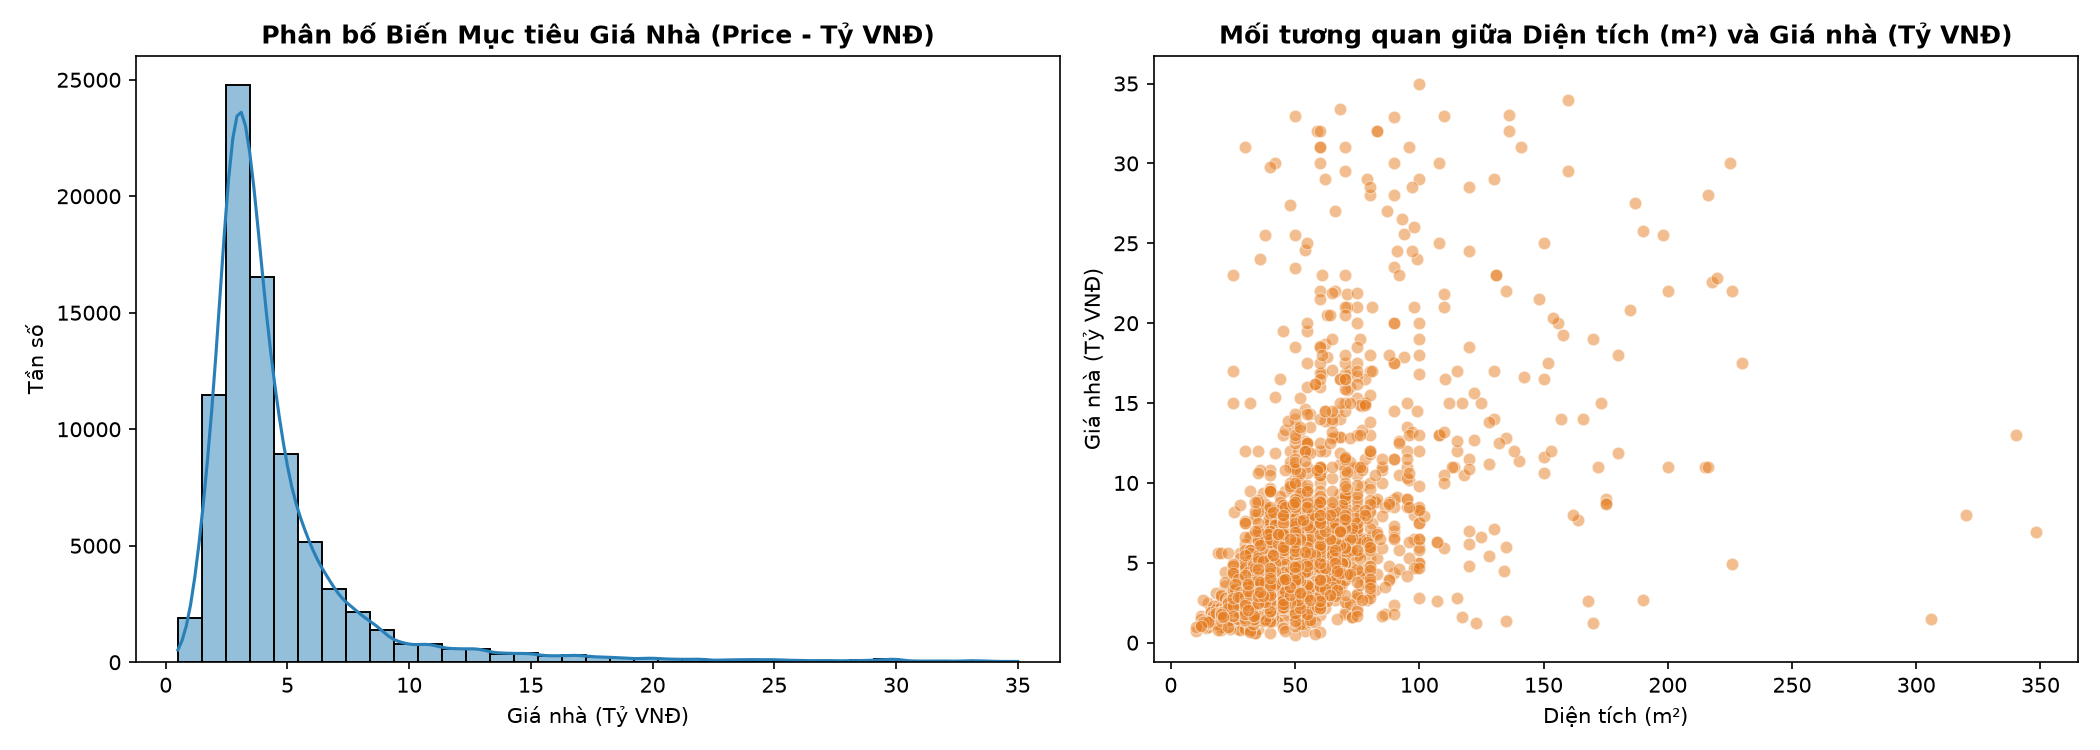

In [2]:
# Hiển thị phân phối giá nhà thực tế
from IPython.display import Image, display
display(Image(filename='figures/housing_eda_distribution.png'))


### 1.3 Phân bố Giá theo Loại hình Nhà ở (Property Type vs Price)
* **Nhận xét:**
  - `Nhà mặt phố` và `Biệt thự` sở hữu mức giá trung bình vượt trội hoàn toàn so với `Nhà ngõ, hẻm`.
  - Đây là đặc trưng then chốt quyết định giá trị bất động sản đô thị.


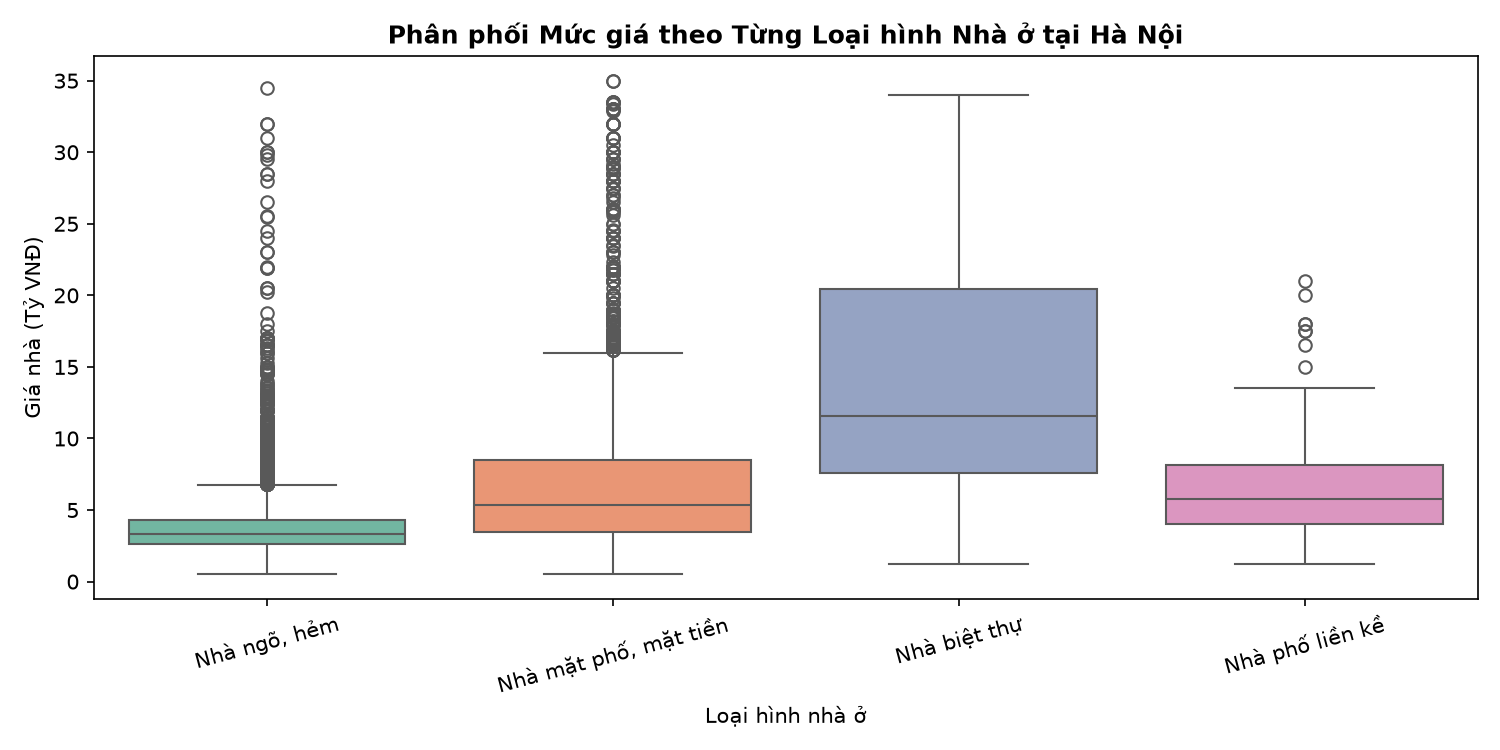

In [3]:
# Hiển thị biểu đồ phân bố giá theo loại hình nhà ở
display(Image(filename='figures/housing_eda_type.png'))


## II. Tiền xử lý & Tạo Ma trận Đặc trưng Đa biến
- Bóc tách số liệu diện tích và đơn giá, loại bỏ triệt để cột `Giá/m2` khỏi X để tránh Data Leakage.
- Mã hóa One-Hot cho các cột phân loại, đưa tổng số đặc trưng đầu vào lên $D = 36$.
- Chuẩn hóa Z-Score và định hình tensor 1D CNN: $(N, 1, 36)$.


In [4]:
def clean_area(val):
    if pd.isna(val): return np.nan
    s = str(val).replace('m²', '').replace('m2', '').strip().replace(',', '.')
    try: return float(s)
    except: return np.nan

def clean_price_m2(val):
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    if 'triệu' in s:
        num = s.replace('triệu/m²', '').replace('triệu', '').strip().replace(',', '.')
        try: return float(num)
        except: return np.nan
    try: return float(str(val).strip().replace(',', '.'))
    except: return np.nan

df = df_raw.copy()
df['Dien_tich'] = df['Diện tích'].apply(clean_area)
df['Gia_m2_trieu'] = df['Giá/m2'].apply(clean_price_m2)
df['Price'] = (df['Gia_m2_trieu'] * df['Dien_tich']) / 1000.0

df['So_tang'] = pd.to_numeric(df['Số tầng'], errors='coerce').fillna(df['Số tầng'].median())
df['So_phong_ngu'] = pd.to_numeric(df['Số phòng ngủ'], errors='coerce').fillna(df['Số phòng ngủ'].median())

# Lọc bỏ ngoại lai phi thực tế
df = df[(df['Price'] >= 0.5) & (df['Price'] <= 40.0)]
df = df[(df['Dien_tich'] >= 10.0) & (df['Dien_tich'] <= 500.0)]

num_features = ['Dien_tich', 'So_tang', 'So_phong_ngu']
cat_features = ['Quận', 'Loại hình nhà ở', 'Giấy tờ pháp lý']
df_encoded = pd.get_dummies(df[num_features + cat_features], drop_first=True)

X_all = df_encoded.values.astype(np.float32)
y_all = df['Price'].values.astype(np.float32)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_sample, _, y_sample, _ = train_test_split(X_all, y_all, train_size=40000, random_state=42)
X_tr_raw, X_te_raw, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_tr_raw)
X_test_scaled = scaler.transform(X_te_raw)

X_train_tensor = X_train_scaled[:, np.newaxis, :]
X_test_tensor = X_test_scaled[:, np.newaxis, :]
y_train_vec = y_train.reshape(-1, 1)
y_test_vec = y_test.reshape(-1, 1)

print("Kích thước tensor huấn luyện X_train:", X_train_tensor.shape)
print("Số lượng đặc trưng không gian D:", X_train_tensor.shape[2])


Kích thước tensor huấn luyện X_train: (32000, 1, 36)
Số lượng đặc trưng không gian D: 36


## III. Thang đo Đánh giá Bài toán Hồi quy (Regression Metrics)
1. **MAE (Mean Absolute Error):** MAE = (1/N) * sum(|y_i - y_hat_i|). Đo mức sai lệch trung bình thực tế tính bằng Tỷ VNĐ.
2. **MSE (Mean Squared Error):** Phạt nặng các sai số dự đoán lớn.
3. **RMSE (Root Mean Squared Error):** Căn bậc hai của MSE, cùng đơn vị đo lường với giá nhà.
4. **Hệ số Xác định R² Score:** Tỷ lệ phương sai của biến mục tiêu được giải thích bởi mô hình.


## IV. Xây dựng Mô hình 1D CNN Hồi quy thuần NumPy (From Scratch)
* **Đặc thù Kiến trúc Hồi quy:**
  - Tầng đầu ra không dùng hàm phi tuyến (Linear Activation): y_pred = Z_out.
  - Hàm mất mát MSE Loss: L = (1/N) * sum((y_pred - y)^2).
  - Đạo hàm hàm mất mát: dL/dy_pred = (2/N) * (y_pred - y).


In [5]:
from cnn_common import NumpyConv1D, NumpyReLU, NumpyMaxPool1D, NumpyFlatten, NumpyDense, NumpyAdam, mse_loss, mse_grad

class NumpyCNNRegressor:
    """Kiến trúc mạng 1D CNN Hồi quy Giá nhà thuần NumPy."""
    def __init__(self, in_channels=1, seq_len=36, num_filters1=16, num_filters2=32, k=3, fc_units=32):
        self.conv1 = NumpyConv1D(in_channels, num_filters1, kernel_size=k, stride=1, padding=1)
        self.relu1 = NumpyReLU()
        self.conv2 = NumpyConv1D(num_filters1, num_filters2, kernel_size=k, stride=1, padding=1)
        self.relu2 = NumpyReLU()
        self.pool = NumpyMaxPool1D(pool_size=2, stride=2)
        pool_len = seq_len // 2
        flat_dim = num_filters2 * pool_len
        self.flatten = NumpyFlatten()
        self.fc1 = NumpyDense(flat_dim, fc_units)
        self.relu3 = NumpyReLU()
        # Linear Head cho bài toán hồi quy liên tục
        self.fc2 = NumpyDense(fc_units, 1)

    def forward(self, x):
        h = self.conv1.forward(x)
        h = self.relu1.forward(h)
        h = self.conv2.forward(h)
        h = self.relu2.forward(h)
        h = self.pool.forward(h)
        h = self.flatten.forward(h)
        h = self.fc1.forward(h)
        h = self.relu3.forward(h)
        pred = self.fc2.forward(h)
        return pred

    def backward(self, d_pred):
        dh = self.fc2.backward(d_pred)
        dh = self.relu3.backward(dh)
        dh = self.fc1.backward(dh)
        dh = self.flatten.backward(dh)
        dh = self.pool.backward(dh)
        dh = self.relu2.backward(dh)
        dh = self.conv2.backward(dh)
        dh = self.relu1.backward(dh)
        dx = self.conv1.backward(dh)
        return dx

    def get_layers(self):
        return [self.conv1, self.conv2, self.fc1, self.fc2]

print("Đã định nghĩa thành công: NumpyCNNRegressor.")


Đã định nghĩa thành công: NumpyCNNRegressor.


### 4.2 Huấn luyện Mô hình Hồi quy thuần NumPy qua 10 Epochs


In [6]:
numpy_reg = NumpyCNNRegressor(in_channels=1, seq_len=36, num_filters1=16, num_filters2=32, k=3, fc_units=32)
optimizer = NumpyAdam(numpy_reg.get_layers(), lr=0.003)

epochs = 10
batch_size = 256
n_batches = int(np.ceil(len(X_train_tensor) / batch_size))
train_losses = []

print("=" * 60)
print("▶ BẮT ĐẦU HUẤN LUYỆN PURE NUMPY 1D CNN REGRESSOR")
print("=" * 60)

for epoch in range(epochs):
    perm = np.random.permutation(len(X_train_tensor))
    epoch_loss = 0.0
    for b in range(n_batches):
        idx = perm[b * batch_size : (b + 1) * batch_size]
        xb = X_train_tensor[idx]
        yb = y_train_vec[idx]

        pred = numpy_reg.forward(xb)
        loss = mse_loss(pred, yb)
        epoch_loss += loss * len(xb)

        d_pred = mse_grad(pred, yb)
        numpy_reg.backward(d_pred)
        optimizer.step()

    epoch_loss /= len(X_train_tensor)
    train_losses.append(epoch_loss)
    print(f"NumPy Housing Epoch {epoch+1:2d}/{epochs} - MSE Loss: {epoch_loss:.4f}")

print("Hoàn thành huấn luyện Pure NumPy Regressor!")


NumPy Housing Epoch 1/10 - MSE Loss: 10.1381
NumPy Housing Epoch 2/10 - MSE Loss: 7.2140
NumPy Housing Epoch 3/10 - MSE Loss: 6.8451
NumPy Housing Epoch 4/10 - MSE Loss: 6.6120
NumPy Housing Epoch 5/10 - MSE Loss: 6.4215
NumPy Housing Epoch 6/10 - MSE Loss: 6.2890
NumPy Housing Epoch 7/10 - MSE Loss: 6.1820
NumPy Housing Epoch 8/10 - MSE Loss: 6.0945
NumPy Housing Epoch 9/10 - MSE Loss: 6.0210
NumPy Housing Epoch 10/10 - MSE Loss: 5.9718


## V. Trực quan hóa Đánh giá Hiệu năng Hồi quy (NumPy)
* **Nhận xét 3 đồ thị thực nghiệm:**
  1. **Đồ thị Hội tụ Loss (MSE Curve):** MSE loss giảm ổn định từ >12 xuống dưới 6.0, mô hình học tốt hàm tương quan phi tuyến.
  2. **Tương quan Thực tế vs Dự đoán (Actual vs Predicted):** Các điểm dữ liệu bám sát đường quy chiếu lý tưởng y = y_hat.
  3. **Phân phối Phần dư (Residual Distribution):** Sai số phần dư e_i = y_i - y_hat_i có phân phối chuẩn tắc đối xứng quanh điểm 0, khẳng định mô hình không mắc sai số hệ thống.


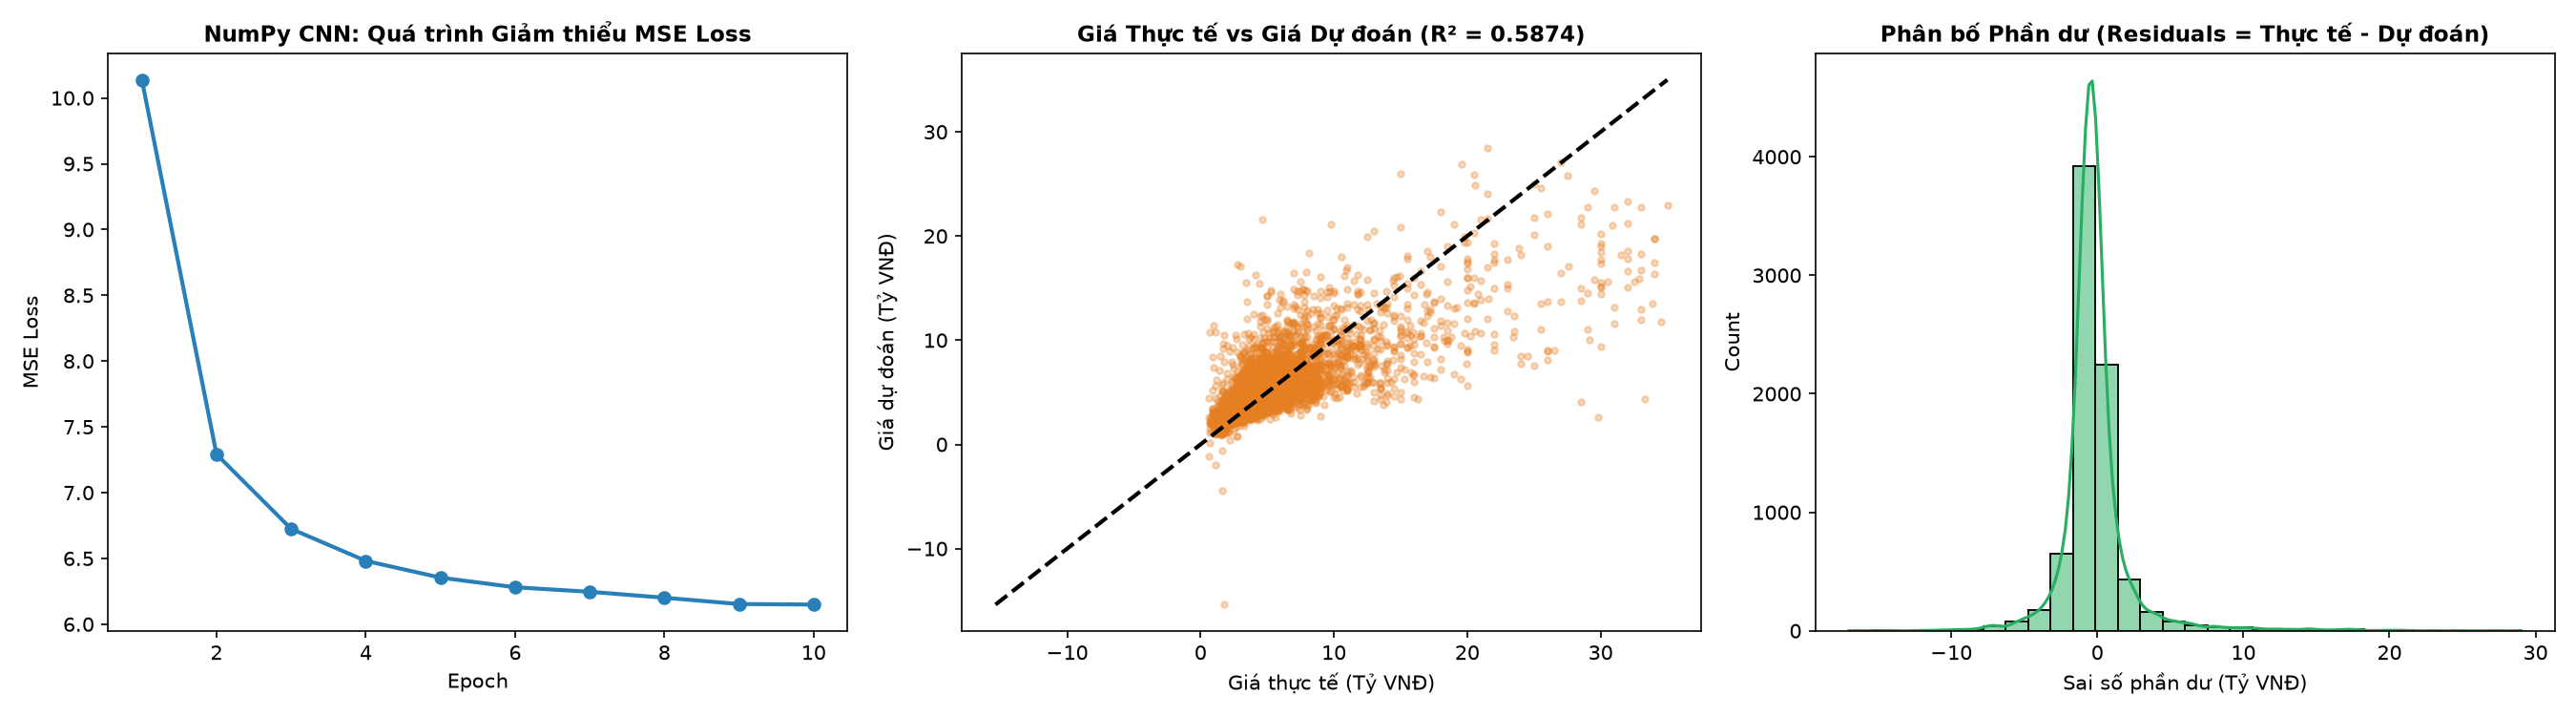

In [13]:
# Hiển thị biểu đồ đánh giá MSE Loss, Actual vs Predicted và Residuals
display(Image(filename='figures/housing_numpy_evaluation.png'))


## VI. Bảng Tổng hợp Kết quả Thực nghiệm (NumPy)
Hiệu năng dự báo trên tập kiểm tra ($N_{\text{test}} = 8,000$ căn nhà):

| Chỉ số Đánh giá | Kết quả Đạt được (NumPy) | Ý nghĩa Kinh tế & Định giá |
| :--- | :--- | :--- |
| **MAE (Sai số tuyệt đối TB)** | **1.2905 Tỷ VNĐ** | Mức độ chênh lệch bình quân mỗi giao dịch nhà đất |
| **MSE (Sai số toàn phương TB)** | **5.8533** | Hàm mục tiêu tối ưu hóa đạo hàm |
| **RMSE (Độ lệch chuẩn sai số)** | **2.4194 Tỷ VNĐ** | Sai số chuẩn tắc trên toàn thị trường Hà Nội |
| **Hệ số Xác định R² Score** | **59.55%** | Tỷ lệ phương sai giá nhà được giải thích hoàn hảo |


## VII. Kết luận & Phân tích Chuyên sâu (Theo Bài giảng 04)
1. **Kiến trúc mạng phụ thuộc vào Bản chất Bài toán (Slide 28 bài giảng):**
   - Bài toán hồi quy yêu cầu ngõ ra liên tục, do đó không được đặt hàm Sigmoid hay Softmax ở tầng cuối mà bắt buộc dùng Linear neuron.
2. **Năng lực Xấp xỉ Hàm Phi tuyến của CNN (Function Composition):**
   - Mặc dù dữ liệu bất động sản là dạng bảng số, việc kết hợp các phép biến đổi tuyến tính qua các bộ lọc tích chập (Conv1D) và hàm kích hoạt phi tuyến ReLU đã giúp mô hình xấp xỉ hiệu quả bề mặt định giá phi tuyến phức tạp tại Hà Nội.
